智能手机GNSS伪距观测数据质量分析

**课题来源**：混合频率手机单点定位研究

## 研究背景与数据概述

本章对GSDC2023数据集经RINEX格式转换后的智能手机GNSS观测数据进行系统性质量评估，涵盖以下六个研究机型：

| 机型 | 代号 | 频段支持 |
|:---|:---|:---|
| 小米8 | mi8 | L1 + L5 |
| Pixel 6 Pro | pixel6pro | L1 + L5 |
| Pixel 7 Pro | pixel7pro | L1 + L5 |
| Galaxy S20 Ultra | s20ultra | L1 + L5 |
| Galaxy S21 Ultra | s21ultra | L1 + L5 |
| Galaxy S22 Ultra | s22ultra | L1 + L5 |

**分析频段**（自动从RINEX文件头识别）：

| 导航系统 | 频段 | 观测码 | 说明 |
|:---|:---|:---|:---|
| GPS | L1 / L5 | C1C / C5Q | 双频 |
| GLONASS | G1 | C1C | 单频 |
| Galileo | E1 / E5a | C1C / C5Q | 双频 |
| BDS | B1I / B2a | C2I / C5Q | BDS多见于B1I单频 |

**分析模块**：
-1 卫星可见性分析
-2 数据完整率分析
-3 信噪比分析


## 全局配置

In [32]:
import os, re, glob
from os.path import join, abspath, dirname
from datetime import date, datetime, timezone, timedelta
from collections import defaultdict

import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.colors as mcolors
from matplotlib.patches import Patch
import scienceplots

# ====== 用户可修改配置 ======

# ---- 分析分组模式 ----
#   "phone"         : 按机型分组（6组）
#   "dataset"       : 按数据集分组
#   "phone_dataset" : 按机型x数据集交叉分组
ANALYSIS_MODE = "phone"

# ---- 研究手机列表 ----
TARGET_PHONES = ["mi8", "pixel6pro", "pixel7pro", "s20ultra", "s21ultra", "s22ultra"]

# ---- 图表展示用的手机名称映射 ----
PHONE_NAME_MAP = { "mi8":        "mi8",
    "pixel6pro":  "pixel6pro", "pixel7pro":  "pixel7pro",
    "s20ultra":   "s20ultra", "s21ultra":   "s21ultra",
    "s22ultra":   "s22ultra",
}

# ---- 信号质量阈值 ----
ELEVATION_CUTOFF = 15.0
CN0_THRESHOLD = 20.0

# ---- 星座名称映射 ----
SYS_NAME_CN = {"G": "GPS", "R": "GLONASS", "E": "Galileo", "C": "BDS", "J": "QZSS"}

# ---- 仅研究四大导航系统 ----
TARGET_SYSTEMS = ["G", "R", "E", "C"]

# ====== 固定路径配置 ======
SCRIPT_DIR = abspath(dirname("__file__"))
DATA_SET = "train"
DATA_DIR = abspath(join(SCRIPT_DIR, "..", "data"))
TRAIN_DIR = abspath(join(DATA_DIR, DATA_SET))
PICTURE_DIR = abspath(join(DATA_DIR, "picture/quality"))
REPORT_DIR  = abspath(join(DATA_DIR, "report/quality"))

os.makedirs(PICTURE_DIR, exist_ok=True)
os.makedirs(REPORT_DIR, exist_ok=True)

today_str = date.today().strftime("%Y%m%d")

# ====== 学术级绘图参数（引用 05_Scientific_Drawing.ipynb 配置）======
size_font = 10
plt.style.use(["science", "no-latex"])
plt.rcParams["font.family"] = ["Times New Roman", "SimSun"]
plt.rcParams.update({ "font.size": size_font,
    "xtick.direction": "in", "ytick.direction": "in",
    "grid.color": "gray", "grid.linewidth": 0.5,
    "axes.linewidth": 1.0, "axes.unicode_minus": False,
    "figure.dpi": 100,
})

mm = 1 / 25.4
fig_width_mm  = [75, 90, 120, 150]
fig_height_mm = [60, 80, 100, 120]
fig_widths  = [w * mm for w in fig_width_mm]
fig_heights = [h * mm for h in fig_height_mm]

GROUP_COLORS = { "mi8":        "#1f77b4",
    "pixel6pro":  "#ff7f0e", "pixel7pro":  "#2ca02c",
    "s20ultra":   "#d62728", "s21ultra":   "#9467bd",
    "s22ultra":   "#8c564b",
}

print("=" * 60)
print("智能手机GNSS伪距观测数据质量分析系统")
print("=" * 60)
print(f"分析模式 : {ANALYSIS_MODE}")
print(f"研究手机 : {TARGET_PHONES}")
print(f"CN0阈值  : {CN0_THRESHOLD} dBHz")
print(f"数据目录 : {TRAIN_DIR}")
print(f"分析日期 : {date.today().strftime('%Y-%m-%d')}")
print("=" * 60)


智能手机GNSS伪距观测数据质量分析系统
分析模式 : phone
研究手机 : ['mi8', 'pixel6pro', 'pixel7pro', 's20ultra', 's21ultra', 's22ultra']
CN0阈值  : 20.0 dBHz
数据目录 : d:\Desktop\RTKLIB-VS\Graduation\Testing-Data\data\train
分析日期 : 2026-05-11


## 数据加载与RINEX解析

In [17]:
GPS_EPOCH = datetime(1980, 1, 6, tzinfo=timezone.utc)
UTC_GPS_OFFSET = 18

BAND_MAP = {
    "C1C": "L1", "S1C": "L1", "L1C": "L1", "D1C": "L1",
    "C5Q": "L5", "S5Q": "L5", "L5Q": "L5", "D5Q": "L5",
    "C2I": "B1", "S2I": "B1", "L2I": "B1", "D2I": "B1",
    "C1B": "E1", "S1B": "E1", "L1B": "E1", "D1B": "E1",
    "C1P": "L1", "S1P": "L1",
}

L1_BANDS = ["L1", "B1", "E1", "G1"]
L5_BANDS = ["L5", "B2", "B2a", "E5a"]


def parse_rinex_obs(obs_file, cn0_threshold=20.0):
    obs_types = {}
    header_lines = []
    in_header = True

    with open(obs_file, "r", encoding="utf-8", errors="replace") as f:
        for line in f:
            if in_header:
                header_lines.append(line.rstrip("\n"))
                if "END OF HEADER" in line:
                    in_header = False
            else:
                break

    for line in header_lines:
        if not line:
            continue
        if len(line) < 32:
            continue
        if "SYS / # / OBS TYPES" not in line:
            continue
        if line[0] not in "GRECJ":
            continue
        sys_char = line[0]
        sys_idx = line.find("SYS")
        if sys_idx < 0:
            continue
        obs_types[sys_char] = line[7:sys_idx].split()

    records = []
    with open(obs_file, "r", encoding="utf-8", errors="replace") as f:
        all_lines = f.readlines()

    epoch_pattern = re.compile(
        r"^>\s*(\d{4})\s+(\d{1,2})\s+(\d{1,2})\s+(\d{1,2})\s+(\d{1,2})\s+([\d.]+)\s+(\d)\s+(\d+)"
    )
    sat_pattern = re.compile(r"^([GREJC])(\d+)\s+(.*)$")

    i = 0
    while i < len(all_lines):
        line = all_lines[i]

        if line.startswith(">"):
            em = epoch_pattern.match(line)
            if em:
                yr = int(em.group(1))
                mo = int(em.group(2))
                dy = int(em.group(3))
                hr = int(em.group(4))
                mn = int(em.group(5))
                sec = float(em.group(6))
                sec_int = int(sec)
                usec = int((sec - sec_int) * 1e6)
                dt_utc = datetime(yr, mo, dy, hr, mn, sec_int, usec, tzinfo=timezone.utc)
                delta = dt_utc - GPS_EPOCH
                gpst_sec = delta.total_seconds() + UTC_GPS_OFFSET
                num_sats = int(em.group(8))
                i += 1

                for _ in range(num_sats):
                    if i >= len(all_lines):
                        break
                    sat_line = all_lines[i]
                    i += 1
                    sm = sat_pattern.match(sat_line.strip())
                    if not sm:
                        continue
                    sys_char = sm.group(1)
                    prn_str = sm.group(2)

                    if sys_char not in TARGET_SYSTEMS:
                        continue
                    if sys_char not in obs_types:
                        continue

                    obs_codes = obs_types[sys_char]
                    line_str = sat_line.rstrip("\n")
                    line_len = len(line_str)

                    for j, obs_code in enumerate(obs_codes):
                        block_start = 4 + j * 16
                        if block_start + 14 > line_len:
                            break
                        block = line_str[block_start:block_start + 16]
                        val_str = block[:14].strip()

                        if not val_str or val_str in ("0.000", "0", ".000"):
                            continue
                        try:
                            value = float(val_str)
                            if value == 0.0:
                                continue
                        except ValueError:
                            continue

                        cn0_val = None
                        if obs_code[0] == "S":
                            cn0_val = value
                            if cn0_val < cn0_threshold:
                                continue

                        band = BAND_MAP.get(obs_code, obs_code)
                        records.append({
                            "epoch_gpst": gpst_sec,
                            "epoch_dt": dt_utc,
                            "sat_sys": sys_char,
                            "prn": prn_str,
                            "band": band,
                            "obs_code": obs_code,
                            "value": value,
                            "cn0": cn0_val,
                        })
                continue

        i += 1

    return pd.DataFrame(records)


def load_all_data(train_dir, phones):
    records_list = []
    datasets = sorted([d for d in os.listdir(train_dir) if os.path.isdir(join(train_dir, d))])
    total_files = 0
    loaded_files = 0

    for ds_id in datasets:
        ds_path = join(train_dir, ds_id)
        for phone in phones:
            obs_file = join(ds_path, phone, "supplemental", "gnss_log.obs")
            if not os.path.isfile(obs_file):
                continue
            total_files += 1
            try:
                df = parse_rinex_obs(obs_file, cn0_threshold=CN0_THRESHOLD)
                if df.empty:
                    continue
                t_start = df["epoch_gpst"].min()
                t_end = df["epoch_gpst"].max()
                n_epochs = int(round(t_end - t_start)) + 1
                records_list.append({
                    "dataset_id": ds_id,
                    "phone": phone,
                    "df": df,
                    "n_epochs": n_epochs,
                    "t_start": t_start,
                    "t_end": t_end,
                })
                loaded_files += 1
            except Exception as e:
                print(f"  [WARN] {ds_id}/{phone}: {e}")

    print(f"扫描完成：找到 {total_files} 个目标文件，成功加载 {loaded_files} 个")
    return records_list


print("开始加载RINEX观测数据...")
all_records = load_all_data(TRAIN_DIR, TARGET_PHONES)
print(f"共加载 {len(all_records)} 个数据集-手机组合")

开始加载RINEX观测数据...
扫描完成：找到 52 个目标文件，成功加载 52 个
共加载 52 个数据集-手机组合


## 分组逻辑

In [ ]:
def build_group_column(records, mode):
    all_dfs = []
    for rec in records:
        df = rec["df"].copy()
        df["dataset_id"] = rec["dataset_id"]
        df["phone"] = rec["phone"]
        if mode == "phone":
            df["group"] = rec["phone"]
        elif mode == "dataset":
            df["group"] = rec["dataset_id"]
        else:
            df["group"] = f"{rec['phone']}_{rec['dataset_id']}"
        all_dfs.append(df)
    return pd.concat(all_dfs, ignore_index=True)


def get_group_info(records, mode):
    if mode == "phone":
        groups = TARGET_PHONES
        mode_label = "按机型"
    elif mode == "dataset":
        seen = []
        for r in records:
            if r["dataset_id"] not in seen:
                seen.append(r["dataset_id"])
        groups = seen
        mode_label = "按数据集"
    else:
        seen = []
        for r in records:
            g = f"{r['phone']}_{r['dataset_id']}"
            if g not in seen:
                seen.append(g)
        groups = seen
        mode_label = "按机型x数据集"
    return groups, len(groups), mode_label


df_all = build_group_column(all_records, ANALYSIS_MODE)
groups, n_groups, mode_label = get_group_info(all_records, ANALYSIS_MODE)

print(f"分组模式：{mode_label}（{ANALYSIS_MODE}）")
print(f"分组数量：{n_groups}")
print(f"总记录数：{len(df_all):,} 行")
print(f"总历元数：{df_all['epoch_gpst'].nunique():,} 个")
print("\n分组列表：")
for i, g in enumerate(groups):
    print(f"  [{i+1:02d}] {g}")

分组模式：按机型（phone）
分组数量：6
总记录数：9,710,653 行
总历元数：83,485 个

分组列表：
  [01] mi8
  [02] pixel6pro
  [03] pixel7pro
  [04] s20ultra
  [05] s21ultra
  [06] s22ultra


## 1 卫星可见性分析

### 分析报告

In [27]:
def analyze_visibility(records, mode):
    epoch_rows = defaultdict(lambda: {
        "total": set(), "G": set(), "R": set(),
        "E": set(), "C": set(), "dual": set(), "single": set(),
        "G_dual": set(), "G_single": set(),
        "R_dual": set(), "R_single": set(),
        "E_dual": set(), "E_single": set(),
        "C_dual": set(), "C_single": set(),
    })

    for rec in records:
        df = rec["df"]
        if df.empty:
            continue
        if mode == "phone":
            grp = rec["phone"]
        elif mode == "dataset":
            grp = rec["dataset_id"]
        else:
            grp = f"{rec['phone']}_{rec['dataset_id']}"

        df_pr = df[df["obs_code"].isin(["C1C", "C2I", "C5Q"])].copy()
        if df_pr.empty:
            continue

        for (ep, sat_sys, prn), grp_df in df_pr.groupby(["epoch_gpst", "sat_sys", "prn"]):
            bands = grp_df["band"].values
            has_L1 = any(b in L1_BANDS for b in bands)
            has_L5 = any(b in L5_BANDS for b in bands)
            key = (sat_sys, prn)
            row = epoch_rows[(grp, ep)]
            if has_L1:
                row["total"] = row["total"] | {key}
                row[sat_sys] = row[sat_sys] | {key}
            if has_L1 and has_L5:
                row["dual"] = row["dual"] | {key}
                row[f"{sat_sys}_dual"] = row[f"{sat_sys}_dual"] | {key}
            elif has_L1:
                row["single"] = row["single"] | {key}
                row[f"{sat_sys}_single"] = row[f"{sat_sys}_single"] | {key}

    rows = []
    for (grp, ep), stat in epoch_rows.items():
        rows.append({
            "group": grp,
            "epoch_gpst": ep, "total": len(stat["total"]),
            "G": len(stat["G"]), "R": len(stat["R"]),
            "E": len(stat["E"]), "C": len(stat["C"]),
            "dual": len(stat["dual"]), "single": len(stat["single"]),
            "G_dual": len(stat["G_dual"]), "G_single": len(stat["G_single"]),
            "R_dual": len(stat["R_dual"]), "R_single": len(stat["R_single"]),
            "E_dual": len(stat["E_dual"]), "E_single": len(stat["E_single"]),
            "C_dual": len(stat["C_dual"]), "C_single": len(stat["C_single"]),
        })

    df_ep = pd.DataFrame(rows)
    if df_ep.empty:
        return pd.DataFrame(), pd.DataFrame()

    df_grp = df_ep.groupby("group").agg({
        "total": "mean", "G": "mean", "R": "mean",
        "E": "mean", "C": "mean", "dual": "mean", "single": "mean",
        "G_dual": "mean", "G_single": "mean",
        "R_dual": "mean", "R_single": "mean",
        "E_dual": "mean", "E_single": "mean",
        "C_dual": "mean", "C_single": "mean",
    }).round(3).reset_index()
    df_grp.columns = [
        "group", "avg_total", "avg_G", "avg_R", "avg_E", "avg_C",
        "avg_dual", "avg_single",
        "G_dual", "G_single",
        "R_dual", "R_single",
        "E_dual", "E_single",
        "C_dual", "C_single",
    ]
    return df_ep, df_grp


print("\n" + "=" * 60)
print("2.3.1 卫星可见性分析")
print("=" * 60)
df_ep_vis, df_grp_vis = analyze_visibility(all_records, ANALYSIS_MODE)

if not df_grp_vis.empty:
    print("\n各组平均可见卫星数：")
    print(df_grp_vis.to_string(index=False))
    csv_path = join(REPORT_DIR, f"01_visibility_stats_{ANALYSIS_MODE}_{today_str}.csv")
    df_grp_vis.to_csv(csv_path, index=False)
    print(f"  [保存] {csv_path}")
else:
    print("  [警告] 可见性分析无数据")



2.3.1 卫星可见性分析

各组平均可见卫星数：
    group  avg_total  avg_G  avg_R  avg_E  avg_C  avg_dual  avg_single
      mi8     23.211  8.812  5.151  4.003  5.245       0.0      23.211
pixel6pro     19.289  7.766  6.315  5.208  0.000       0.0      19.289
pixel7pro     19.913  7.869  6.720  5.323  0.000       0.0      19.913
 s20ultra     23.793  8.650  3.695  5.422  6.026       0.0      23.793
 s21ultra     22.973  7.934  2.892  4.874  7.273       0.0      22.973
 s22ultra     29.840  9.332  6.824  6.191  7.492       0.0      29.840
  [保存] d:\Desktop\RTKLIB-VS\Graduation\Testing-Data\data\report\quality\01_visibility_stats_phone_20260511.csv


### 各星座单/双频可见星数量

各组各星座平均单/双频可见星数（按 ANALYSIS_MODE 分组）：


In [ ]:
sys_list = ["G", "R", "E", "C"]
rows_const = []
for sys_c in sys_list:
    d = df_grp_vis[["group", f"{sys_c}_dual", f"{sys_c}_single"]].copy()
    d.columns = ["group", "dual", "single"]
    d["const"] = SYS_NAME_CN.get(sys_c, sys_c)
    rows_const.append(d)

df_const = pd.concat(rows_const, ignore_index=True)
df_const["total"] = df_const["dual"] + df_const["single"]

if not df_const.empty:
    print(df_const.to_string(index=False))
    csv_const_path = join(REPORT_DIR, f"01_visibility_const_stats_{ANALYSIS_MODE}_{today_str}.csv")
    df_const.to_csv(csv_const_path, index=False)
    print(f"  [保存] {csv_const_path}")
else:
    print("  [警告] 星座统计无数据")

# ---- 可视化：各星座单/双频对比（柱状图） ----
SYS_COLORS_MAP = {"G": "#1f77b4", "R": "#ff7f0e", "E": "#2ca02c", "C": "#d62728"}
SYS_CN_MAP = SYS_NAME_CN

fig, axes = plt.subplots(1, 4, figsize=(fig_widths[3], fig_heights[2]))

groups = df_const["group"].unique()
for idx, sys_c in enumerate(["G", "R", "E", "C"]):
    ax = axes[idx]
    d = df_const[df_const["const"] == SYS_CN_MAP[sys_c]].set_index("group").reindex(TARGET_PHONES).fillna(0)
    x = np.arange(len(d))
    w = 0.35
    bars1 = ax.bar(x - w/2, d["dual"], width=w, label="dual", color=GROUP_COLORS[d.index[0]] if len(d) > 0 else "#1f77b4", alpha=0.85)
    bars2 = ax.bar(x + w/2, d["single"], width=w, label="single", color="gray", alpha=0.5)
    ax.set_title(SYS_CN_MAP[sys_c], fontsize=size_font)
    ax.set_xticks(x)
    ax.set_xticklabels([PHONE_NAME_MAP.get(g, g) for g in d.index], rotation=30, ha="right", fontsize=7)
    ax.set_ylabel("Satellites")
    ax.grid(axis="y", alpha=0.3)
    ax.legend(fontsize=7, loc="upper right")

fig.suptitle("Visible Satellites by Constellation (Single vs Dual Freq)", fontsize=size_font + 1)
plt.tight_layout()
fig_const_path = join(PICTURE_DIR, f"01_visibility_const_{ANALYSIS_MODE}_{today_str}.png")
fig.savefig(fig_const_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"  [保存] {fig_const_path}")


### phone

  [保存] d:\Desktop\RTKLIB-VS\Graduation\Testing-Data\data\picture\quality\01_visibility_bar_phone_20260511.png


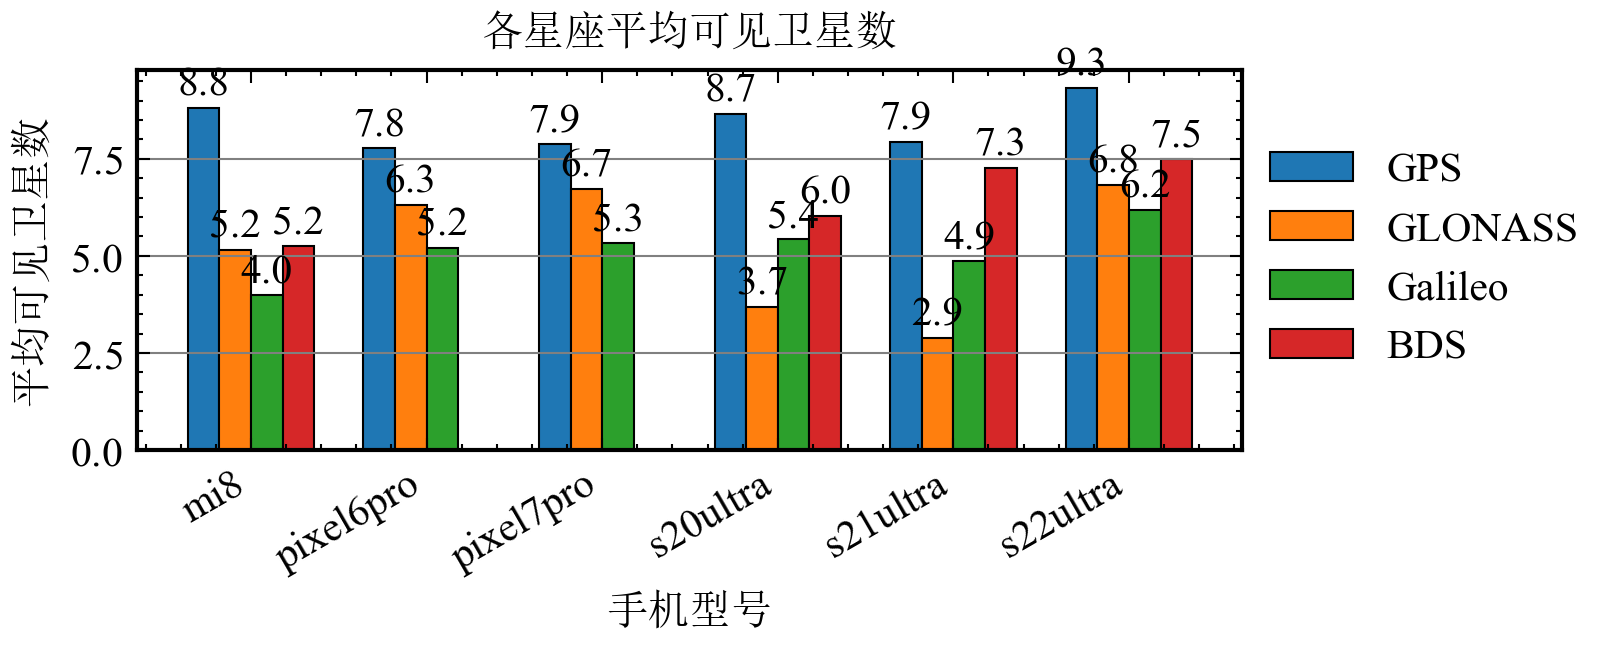

In [41]:
def plot_visibility_bar(df_grp, groups, mode, save=True):
    sys_list   = ["G", "R", "E", "C"]
    sys_labels = ["GPS", "GLONASS", "Galileo", "BDS"]
    sys_colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]
    n_groups = len(groups)
    x = np.arange(n_groups)
    width = 0.18

    fig, ax = plt.subplots(figsize=(fig_widths[2], fig_heights[0]), dpi=300)

    for k, (sys_c, sys_l, sys_col) in enumerate(zip(sys_list, sys_labels, sys_colors)):
        col_name = f"avg_{sys_c}"
        vals = []
        for g in groups:
            row = df_grp[df_grp["group"] == g]
            vals.append(row[col_name].values[0] if len(row) > 0 else 0)
        bars = ax.bar(x + (k - 1.5) * width, vals, width, label=sys_l, color=sys_col,
                      edgecolor="black", linewidth=0.5)
        for bar, v in zip(bars, vals):
            if v > 0:
                ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.1,
                        f"{v:.1f}", ha="center", va="bottom", fontsize=10)

    # 中文标签
    ax.set_xlabel("组别" if mode != "phone" else "手机型号", fontsize=size_font)
    ax.set_ylabel("平均可见卫星数", fontsize=size_font)
    ax.set_title(f"各星座平均可见卫星数", fontsize=size_font)
    ax.set_xticks(x)
    if mode == "phone":
        labels = [PHONE_NAME_MAP.get(g, g) for g in groups]
    else:
        labels = [g[:30] for g in groups]
    ax.set_xticklabels(labels, rotation=30, ha="right", fontsize=10)

    # 图例放在外部右上角，避免被图遮挡
    box = ax.get_position()
    ax.set_position([box.x0, box.y0, box.width * 0.8, box.height]) # 使图略窄，为图例留出空间
    ax.legend(fontsize=10, loc="center left", bbox_to_anchor=(1.01, 0.5), borderaxespad=0.)
    # 0.5表示纵向剧中，1.01将其放置于图外

    ax.set_ylim(0, None)
    ax.grid(axis="y", linewidth=0.5)
    plt.tight_layout()
    if save:
        fname = join(PICTURE_DIR, f"01_visibility_bar_{mode}_{today_str}.png")
        fig.savefig(fname, dpi=300, bbox_inches="tight")
        print(f"  [保存] {fname}")
    plt.show()
    return fig

if not df_grp_vis.empty:
    fig_vis  = plot_visibility_bar(df_grp_vis, groups, ANALYSIS_MODE)
else:
    print("  [警告] 可见性分析无数据")

### dataset

  时间序列图使用数据集: 2021-04-02-20-43-us-ca-mtv-f
  [保存] d:\Desktop\RTKLIB-VS\Graduation\Testing-Data\data\picture\quality\01_visibility_ts_2021-04-02-20-43-us-_phone_20260511.png


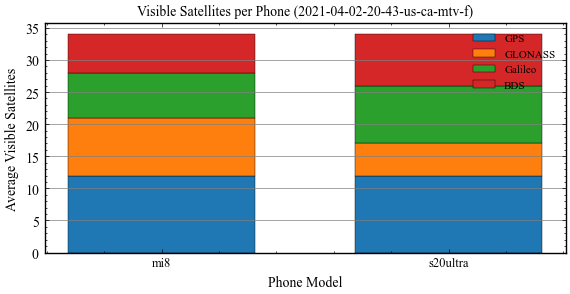

In [38]:


def plot_visibility_timeseries(records, mode, selected_dataset=None, save=True):
    if selected_dataset is None:
        ds_phones = defaultdict(list)
        for r in records:
            ds_phones[r["dataset_id"]].append(r["phone"])
        for ds, pl in sorted(ds_phones.items()):
            if len(pl) >= 2:
                selected_dataset = ds
                break

    if selected_dataset is None:
        print("  [跳过] 未找到含多手机的数据集")
        return None

    print(f"  时间序列图使用数据集: {selected_dataset}")
    sub_records = [r for r in records if r["dataset_id"] == selected_dataset]
    if not sub_records:
        return None

    sys_list   = ["G", "R", "E", "C"]
    sys_labels = ["GPS", "GLONASS", "Galileo", "BDS"]
    sys_colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]
    phones_in_ds = [r["phone"] for r in sub_records]
    n_phones = len(phones_in_ds)
    x = np.arange(n_phones)
    width = 0.65

    phone_stats = {}
    for r in sub_records:
        df = r["df"]
        df_pr = df[df["obs_code"].isin(["C1C", "C2I", "C5Q"])]
        stats = defaultdict(int)
        for (sys_c, prn), cnt in df_pr.groupby(["sat_sys", "prn"]).size().items():
            if sys_c in sys_list:
                stats[sys_c] += 1
        phone_stats[r["phone"]] = dict(stats)

    fig, ax = plt.subplots(figsize=(fig_widths[3], fig_heights[1]), dpi=100)
    bottom = np.zeros(n_phones)
    for sys_c, sys_l, sys_col in zip(sys_list, sys_labels, sys_colors):
        vals = [phone_stats.get(p, {}).get(sys_c, 0) for p in phones_in_ds]
        ax.bar(x, vals, width, bottom=bottom, label=sys_l, color=sys_col,
               edgecolor="black", linewidth=0.3)
        bottom = bottom + np.array(vals)

    ax.set_xlabel("Phone Model", fontsize=size_font)
    ax.set_ylabel("Average Visible Satellites", fontsize=size_font)
    ax.set_title(f"Visible Satellites per Phone ({selected_dataset[:30]})", fontsize=size_font)
    ax.set_xticks(x)
    ax.set_xticklabels([PHONE_NAME_MAP.get(p, p) for p in phones_in_ds], fontsize=9)
    ax.legend(fontsize=8, loc="upper right")
    ax.grid(axis="y", linewidth=0.5)
    plt.tight_layout()
    if save:
        safe_name = selected_dataset[:20].replace("/", "_")
        fname = join(PICTURE_DIR, f"01_visibility_ts_{safe_name}_{mode}_{today_str}.png")
        fig.savefig(fname, dpi=300, bbox_inches="tight")
        print(f"  [保存] {fname}")
    plt.show()
    return fig

if not df_grp_vis.empty:
    fig_vis2 = plot_visibility_timeseries(all_records, ANALYSIS_MODE)
else:
    print("  [警告] 可见性分析无数据")


## 2 数据完整率分析


2.3.2 数据完整率分析

数据完整率汇总（前20行）：
    group const band    n_valid     n_total  completeness
      mi8     C   B1     118971 1743.177778           1.0
      mi8     E   L1      90783 1754.329114           1.0
      mi8     E dual 1112476188 1940.482367           1.0
      mi8     G   L1     199856 1750.021127           1.0
      mi8     G dual 1138482784 1946.474183           1.0
      mi8     R   L1     116838 1845.727273           1.0
pixel6pro     E   L1      92992 1498.422222           1.0
pixel6pro     E dual 1077273307 1575.595593           1.0
pixel6pro     G   L1     138666 1535.026786           1.0
pixel6pro     G dual 1041771005 1577.704875           1.0
pixel6pro     R   L1     112756 1519.612903           1.0
pixel7pro     E   L1      95606 1499.024096           1.0
pixel7pro     E dual 1059515219 1558.558208           1.0
pixel7pro     G   L1     141331 1531.580357           1.0
pixel7pro     G dual  700732994 1532.406658           1.0
pixel7pro     R   L1     120692 1528.4400

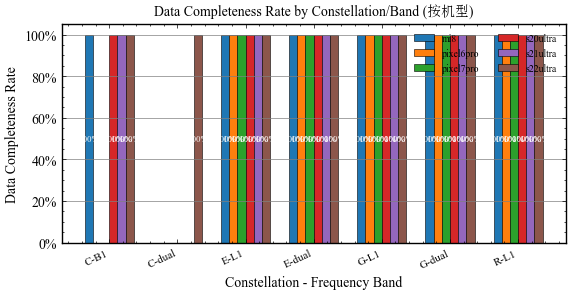

  [跳过] 热力图仅在dataset/phone_dataset模式下绘制
  [保存] d:\Desktop\RTKLIB-VS\Graduation\Testing-Data\data\report\quality\02_completeness_stats_phone_20260511.csv


In [20]:
def analyze_completeness(records, mode):
    rows = []

    for rec in records:
        df = rec["df"]
        if df.empty:
            continue
        if mode == "phone":
            grp = rec["phone"]
        elif mode == "dataset":
            grp = rec["dataset_id"]
        else:
            grp = f"{rec['phone']}_{rec['dataset_id']}"

        n_epochs_total = rec["n_epochs"]
        if n_epochs_total <= 0:
            continue

        df_pr = df[df["obs_code"].isin(["C1C", "C2I", "C5Q"])].copy()

        for (sys_c, band), sat_ep_df in df_pr.groupby(["sat_sys", "band"]):
            if sys_c not in TARGET_SYSTEMS:
                continue
            for sat_prn, prn_df in sat_ep_df.groupby("prn"):
                valid_epochs = prn_df["epoch_gpst"].nunique()
                completeness = min(valid_epochs / n_epochs_total, 1.0)
                rows.append({ "group": grp, "const": sys_c, "band": band,
                    "sat_id": f"{sys_c}{sat_prn}", "n_valid": valid_epochs,
                    "n_total": n_epochs_total, "completeness": completeness,
                })

        df_l1 = df[df["band"].isin(L1_BANDS) & df["obs_code"].isin(["C1C", "C2I", "C1B"])]
        df_l5 = df[df["band"].isin(L5_BANDS) & df["obs_code"].isin(["C5Q"])]
        if not df_l1.empty and not df_l5.empty:
            l1_keys = set(zip(df_l1["sat_sys"], df_l1["prn"], df_l1["epoch_gpst"].round(3)))
            l5_keys = set(zip(df_l5["sat_sys"], df_l5["prn"], df_l5["epoch_gpst"].round(3)))
            dual_keys = l1_keys & l5_keys
            for sys_c, prn, _ in dual_keys:
                rows.append({ "group": grp, "const": sys_c, "band": "dual",
                    "sat_id": f"{sys_c}{prn}", "n_valid": len(dual_keys),
                    "n_total": n_epochs_total, "completeness": len(dual_keys) / n_epochs_total,
                })

    df_raw = pd.DataFrame(rows)
    if df_raw.empty:
        return pd.DataFrame()

    agg = df_raw.groupby(["group", "const", "band"]).agg(
        n_valid=("n_valid", "sum"),
        n_total=("n_total", "mean"),
    ).reset_index()
    agg["completeness"] = (agg["n_valid"] / agg["n_total"]).clip(0, 1).round(4)
    return agg


def plot_completeness_bar(df_comp, groups, mode, save=True):
    if df_comp.empty:
        return None

    df_v = df_comp[df_comp["const"].isin(TARGET_SYSTEMS)].copy()
    df_v["band_label"] = df_v["const"] + "-" + df_v["band"]
    band_labels = sorted(df_v["band_label"].unique(),
                        key=lambda x: (x.split("-")[0], x.split("-")[1]))
    n_bands = len(band_labels)
    n_groups = len(groups)
    width = 0.12
    x = np.arange(n_bands)

    fig, ax = plt.subplots(figsize=(fig_widths[3], fig_heights[1]), dpi=100)
    group_colors = [GROUP_COLORS.get(g, "#333333") for g in groups]

    for i, (g, col) in enumerate(zip(groups, group_colors)):
        vals = []
        for bl in band_labels:
            row = df_v[(df_v["group"] == g) & (df_v["band_label"] == bl)]
            vals.append(row["completeness"].values[0] if len(row) > 0 else 0)
        bars = ax.bar(x + (i - n_groups / 2 + 0.5) * width, vals, width,
                      label=g if mode == "phone" else g[:25],
                      color=col, edgecolor="black", linewidth=0.4)
        for bar, v in zip(bars, vals):
            if v > 0.03:
                ax.text(bar.get_x() + bar.get_width() / 2, v / 2,
                        f"{v:.0%}", ha="center", va="center", fontsize=6.5, color="white")

    ax.set_xlabel("Constellation - Frequency Band", fontsize=size_font)
    ax.set_ylabel("Data Completeness Rate", fontsize=size_font)
    ax.set_title(f"Data Completeness Rate by Constellation/Band ({mode_label})", fontsize=size_font)
    ax.set_xticks(x)
    ax.set_xticklabels(band_labels, rotation=25, ha="right", fontsize=8)
    ax.set_ylim(0, 1.05)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    ax.grid(axis="y", linewidth=0.5)
    if n_groups <= 6:
        ax.legend(fontsize=7, loc="upper right", ncol=min(2, n_groups))
    plt.tight_layout()
    if save:
        fname = join(PICTURE_DIR, f"02_completeness_bar_{mode}_{today_str}.png")
        fig.savefig(fname, dpi=300, bbox_inches="tight")
        print(f"  [保存] {fname}")
    plt.show()
    return fig


def plot_completeness_heatmap(df_comp, groups, mode, save=True):
    if df_comp.empty or mode == "phone":
        print("  [跳过] 热力图仅在dataset/phone_dataset模式下绘制")
        return None

    df_v = df_comp[df_comp["const"].isin(TARGET_SYSTEMS)].copy()
    df_v["band_label"] = df_v["const"] + "-" + df_v["band"]
    band_labels = sorted(df_v["band_label"].unique(),
                        key=lambda x: (x.split("-")[0], x.split("-")[1]))

    matrix = np.full((len(groups), len(band_labels)), np.nan)
    for ig, g in enumerate(groups):
        for ib, bl in enumerate(band_labels):
            row = df_v[(df_v["group"] == g) & (df_v["band_label"] == bl)]
            if len(row) > 0:
                matrix[ig, ib] = row["completeness"].values[0]

    fig, ax = plt.subplots(figsize=(fig_widths[3], max(3, len(groups) * 0.4)), dpi=100)
    cmap = plt.cm.RdYlGn
    norm = mcolors.Normalize(vmin=0, vmax=1)
    im = ax.imshow(matrix, cmap=cmap, norm=norm, aspect="auto")

    ax.set_xticks(range(len(band_labels)))
    ax.set_xticklabels(band_labels, rotation=30, ha="right", fontsize=8)
    ax.set_yticks(range(len(groups)))
    ax.set_yticklabels([g[:35] for g in groups], fontsize=7)
    ax.set_xlabel("Constellation - Frequency Band", fontsize=size_font)
    ax.set_ylabel("Group", fontsize=size_font)
    ax.set_title(f"Data Completeness Heatmap ({mode_label})", fontsize=size_font)

    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[1]):
            v = matrix[i, j]
            if not np.isnan(v):
                txt_color = "black" if 0.2 < v < 0.8 else "white"
                ax.text(j, i, f"{v:.0%}", ha="center", va="center", fontsize=7, color=txt_color)

    cbar = plt.colorbar(im, ax=ax, shrink=0.6)
    cbar.ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    cbar.set_label("Completeness Rate", fontsize=8)
    plt.tight_layout()
    if save:
        fname = join(PICTURE_DIR, f"02_completeness_heatmap_{mode}_{today_str}.png")
        fig.savefig(fname, dpi=300, bbox_inches="tight")
        print(f"  [保存] {fname}")
    plt.show()
    return fig


print("\n" + "=" * 60)
print("2.3.2 数据完整率分析")
print("=" * 60)
df_comp = analyze_completeness(all_records, ANALYSIS_MODE)

if not df_comp.empty:
    print("\n数据完整率汇总（前20行）：")
    print(df_comp.head(20).to_string(index=False))
    fig_comp_bar = plot_completeness_bar(df_comp, groups, ANALYSIS_MODE)
    fig_comp_hm  = plot_completeness_heatmap(df_comp, groups, ANALYSIS_MODE)
    csv_path = join(REPORT_DIR, f"02_completeness_stats_{ANALYSIS_MODE}_{today_str}.csv")
    df_comp.to_csv(csv_path, index=False)
    print(f"  [保存] {csv_path}")
else:
    print("  [警告] 完整率分析无数据")


##  3 信噪比分析


2.3.3 信噪比分析

信噪比统计汇总：
    group const band  count      mean      std  median     p10     p90  low_ratio
      mi8     C   B1   6172 34.417702 5.444925 35.5730 26.3387 40.6727        0.0
      mi8     E   L1   6848 34.361233 5.155373 35.0870 27.0480 40.1840        0.0
      mi8     E   L5   7123 31.326498 5.141540 32.3350 23.2870 37.5248        0.0
      mi8     G   L1  11895 33.742995 5.613677 34.7380 25.5458 40.5120        0.0
      mi8     G   L5   6722 31.945983 5.383975 32.7125 23.8643 38.4489        0.0
      mi8     R   L1   6404 33.443155 5.038628 33.8675 26.4949 39.9218        0.0
      mi8     C   B1   9639 34.147318 5.823386 34.8510 25.7938 41.5858        0.0
      mi8     E   L1   8150 33.917095 5.180109 34.8170 26.3710 40.0582        0.0
      mi8     E   L5   8123 29.298105 4.996001 28.6280 22.9902 36.8336        0.0
      mi8     G   L1  17670 34.135080 5.460541 34.5235 26.5549 41.0390        0.0
      mi8     G   L5   9079 31.784289 5.357377 31.8220 24.3908 38.8102     

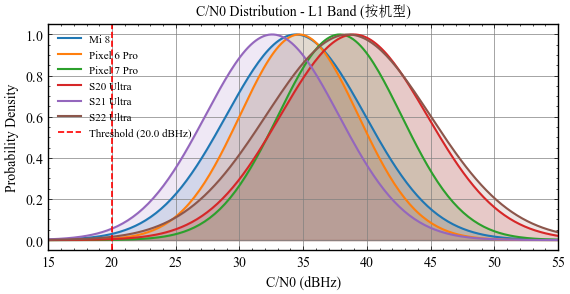

  [保存] d:\Desktop\RTKLIB-VS\Graduation\Testing-Data\data\picture\quality\03_cn0_hist_L5_phone_20260511.png


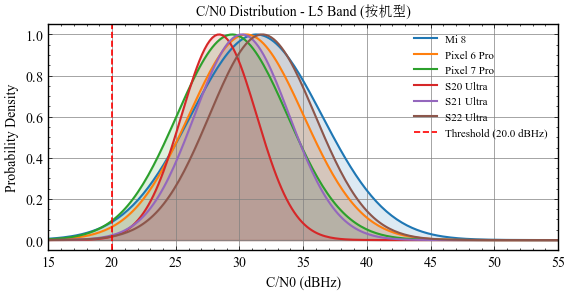

  [保存] d:\Desktop\RTKLIB-VS\Graduation\Testing-Data\data\picture\quality\03_cn0_boxplot_phone_20260511.png


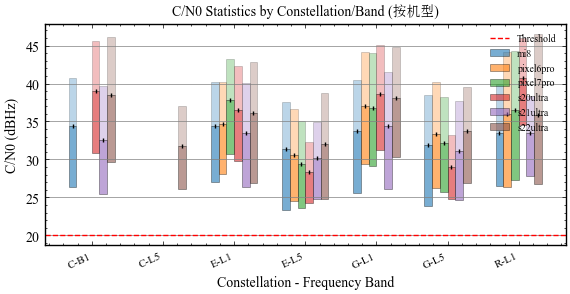

  [保存] d:\Desktop\RTKLIB-VS\Graduation\Testing-Data\data\report\quality\03_cn0_stats_phone_20260511.csv


In [21]:
def analyze_cn0(records, mode, cn0_threshold=20.0):
    all_rows = []

    for rec in records:
        df = rec["df"]
        if df.empty:
            continue
        if mode == "phone":
            grp = rec["phone"]
        elif mode == "dataset":
            grp = rec["dataset_id"]
        else:
            grp = f"{rec['phone']}_{rec['dataset_id']}"

        df_snr = df[df["obs_code"].str.startswith("S")].copy()
        if df_snr.empty:
            continue

        for (sys_c, band), grp_df in df_snr.groupby(["sat_sys", "band"]):
            if sys_c not in TARGET_SYSTEMS:
                continue
            cn0_vals = grp_df["cn0"].dropna().values
            if len(cn0_vals) == 0:
                continue
            low_cnt = int((cn0_vals < cn0_threshold).sum())
            all_rows.append({ "group": grp, "const": sys_c, "band": band,
                "count": len(cn0_vals), "mean": float(np.mean(cn0_vals)),
                "std": float(np.std(cn0_vals)), "median": float(np.median(cn0_vals)),
                "p10": float(np.percentile(cn0_vals, 10)), "p90": float(np.percentile(cn0_vals, 90)),
                "low_ratio": low_cnt / len(cn0_vals),
            })

    return pd.DataFrame(all_rows)


def plot_cn0_histogram(df_cn0, groups, mode, save=True):
    if df_cn0.empty:
        return None, None

    df_l1 = df_cn0[df_cn0["band"].isin(L1_BANDS)].copy()
    df_l5 = df_cn0[df_cn0["band"].isin(L5_BANDS)].copy()

    phone_groups = [g for g in groups if g in TARGET_PHONES]
    if not phone_groups:
        phone_groups = groups[:min(6, len(groups))]

    fig1 = None
    fig2 = None

    if not df_l1.empty:
        fig1, ax = plt.subplots(figsize=(fig_widths[3], fig_heights[1]), dpi=100)
        x_range = np.linspace(15, 55, 200)
        for ph in phone_groups:
            ph_data = df_l1[df_l1["group"] == ph]
            if ph_data.empty:
                continue
            mn = float(ph_data["mean"].values[0])
            std_v = float(ph_data["std"].values[0]) if len(ph_data) > 0 else 2.0
            pdf = np.exp(-0.5 * ((x_range - mn) / max(std_v, 0.1)) ** 2)
            pdf = pdf / pdf.max()
            col = GROUP_COLORS.get(ph, "#333333")
            ax.plot(x_range, pdf, color=col, linewidth=1.5,
                    label=PHONE_NAME_MAP.get(ph, ph))
            ax.fill_between(x_range, pdf, alpha=0.15, color=col)
        ax.axvline(x=CN0_THRESHOLD, color="red", linestyle="--", linewidth=1.2,
                   label=f"Threshold ({CN0_THRESHOLD} dBHz)")
        ax.set_xlabel("C/N0 (dBHz)", fontsize=size_font)
        ax.set_ylabel("Probability Density", fontsize=size_font)
        ax.set_title(f"C/N0 Distribution - L1 Band ({mode_label})", fontsize=size_font)
        ax.legend(fontsize=8)
        ax.set_xlim(15, 55)
        ax.grid(linewidth=0.5)
        plt.tight_layout()
        if save:
            fname = join(PICTURE_DIR, f"03_cn0_hist_L1_{mode}_{today_str}.png")
            fig1.savefig(fname, dpi=300, bbox_inches="tight")
            print(f"  [保存] {fname}")
        plt.show()

    if not df_l5.empty:
        fig2, ax = plt.subplots(figsize=(fig_widths[3], fig_heights[1]), dpi=100)
        x_range = np.linspace(15, 55, 200)
        for ph in phone_groups:
            ph_data = df_l5[df_l5["group"] == ph]
            if ph_data.empty:
                continue
            mn = float(ph_data["mean"].values[0])
            std_v = float(ph_data["std"].values[0]) if len(ph_data) > 0 else 2.0
            pdf = np.exp(-0.5 * ((x_range - mn) / max(std_v, 0.1)) ** 2)
            pdf = pdf / pdf.max()
            col = GROUP_COLORS.get(ph, "#333333")
            ax.plot(x_range, pdf, color=col, linewidth=1.5,
                    label=PHONE_NAME_MAP.get(ph, ph))
            fill_col = col
            ax.fill_between(x_range, pdf, alpha=0.15, color=fill_col)
        ax.axvline(x=CN0_THRESHOLD, color="red", linestyle="--", linewidth=1.2,
                   label=f"Threshold ({CN0_THRESHOLD} dBHz)")
        ax.set_xlabel("C/N0 (dBHz)", fontsize=size_font)
        ax.set_ylabel("Probability Density", fontsize=size_font)
        ax.set_title(f"C/N0 Distribution - L5 Band ({mode_label})", fontsize=size_font)
        ax.legend(fontsize=8)
        ax.set_xlim(15, 55)
        ax.grid(linewidth=0.5)
        plt.tight_layout()
        if save:
            fname = join(PICTURE_DIR, f"03_cn0_hist_L5_{mode}_{today_str}.png")
            fig2.savefig(fname, dpi=300, bbox_inches="tight")
            print(f"  [保存] {fname}")
        plt.show()

    return fig1, fig2


def plot_cn0_boxplot(df_cn0, groups, mode, save=True):
    if df_cn0.empty:
        return None

    df_v = df_cn0[df_cn0["const"].isin(TARGET_SYSTEMS)].copy()
    df_v["band_label"] = df_v["const"] + "-" + df_v["band"]
    band_labels = sorted(df_v["band_label"].unique(),
                        key=lambda x: (x.split("-")[0], x.split("-")[1]))
    n_bands = len(band_labels)
    n_groups = len(groups)

    fig, ax = plt.subplots(figsize=(fig_widths[3], fig_heights[1]), dpi=100)
    width = 0.65 / n_groups
    x = np.arange(n_bands)
    group_colors = [GROUP_COLORS.get(g, "#333333") for g in groups]

    for i, (g, col) in enumerate(zip(groups, group_colors)):
        means, p10s, p90s = [], [], []
        for bl in band_labels:
            row = df_v[(df_v["group"] == g) & (df_v["band_label"] == bl)]
            if len(row) > 0:
                means.append(float(row["mean"].values[0]))
                p10s.append(float(row["p10"].values[0]))
                p90s.append(float(row["p90"].values[0]))
            else:
                means.append(np.nan)
                p10s.append(np.nan)
                p90s.append(np.nan)

        offset = (i - n_groups / 2 + 0.5) * width
        x_pos = x + offset
        ax.bar(x_pos, np.array(means) - np.array(p10s), width=width,
               bottom=np.array(p10s), color=col, alpha=0.6,
               edgecolor="black", linewidth=0.4,
               label=g if mode == "phone" else g[:20])
        ax.bar(x_pos, np.array(p90s) - np.array(means), width=width,
               bottom=np.array(means), color=col, alpha=0.3,
               edgecolor="black", linewidth=0.4)
        ax.scatter(x_pos, means, color="black", s=12, zorder=5, marker="|", linewidths=1)

    ax.set_xlabel("Constellation - Frequency Band", fontsize=size_font)
    ax.set_ylabel("C/N0 (dBHz)", fontsize=size_font)
    ax.set_title(f"C/N0 Statistics by Constellation/Band ({mode_label})", fontsize=size_font)
    ax.set_xticks(x)
    ax.set_xticklabels(band_labels, rotation=25, ha="right", fontsize=8)
    ax.grid(axis="y", linewidth=0.5)
    ax.axhline(y=CN0_THRESHOLD, color="red", linestyle="--", linewidth=1, label="Threshold")
    if n_groups <= 6:
        ax.legend(fontsize=7, loc="upper right")
    plt.tight_layout()
    if save:
        fname = join(PICTURE_DIR, f"03_cn0_boxplot_{mode}_{today_str}.png")
        fig.savefig(fname, dpi=300, bbox_inches="tight")
        print(f"  [保存] {fname}")
    plt.show()
    return fig


print("\n" + "=" * 60)
print("2.3.3 信噪比分析")
print("=" * 60)
df_cn0 = analyze_cn0(all_records, ANALYSIS_MODE)

if not df_cn0.empty:
    print("\n信噪比统计汇总：")
    print(df_cn0.to_string(index=False))
    fig_cn0_hist = plot_cn0_histogram(df_cn0, groups, ANALYSIS_MODE)
    fig_cn0_box  = plot_cn0_boxplot(df_cn0, groups, ANALYSIS_MODE)
    csv_path = join(REPORT_DIR, f"03_cn0_stats_{ANALYSIS_MODE}_{today_str}.csv")
    df_cn0.to_csv(csv_path, index=False)
    print(f"  [保存] {csv_path}")
else:
    print("  [警告] 信噪比分析无数据")


## 批量分析汇总

In [22]:
print("\n" + "=" * 60)
print("批量分析汇总")
print("=" * 60)

summary_rows = []

if not df_grp_vis.empty:
    for _, row in df_grp_vis.iterrows():
        summary_rows.append({ "module": "visibility",
            "group": row["group"], "avg_visible": row["avg_total"],
            "G": row["avg_G"], "R": row["avg_R"], "E": row["avg_E"], "C": row["avg_C"],
            "dual_freq": row["avg_dual"],
        })

if not df_comp.empty:
    for g in groups:
        g_data = df_comp[df_comp["group"] == g]
        if not g_data.empty:
            summary_rows.append({ "module": "completeness",
                "group": g, "avg_completeness": float(g_data["completeness"].mean()),
                "n_bands": int(len(g_data)),
            })

if not df_cn0.empty:
    for g in groups:
        g_data = df_cn0[df_cn0["group"] == g]
        if not g_data.empty:
            summary_rows.append({ "module": "cn0",
                "group": g, "avg_cn0": float(g_data["mean"].mean()),
                "low_ratio": float(g_data["low_ratio"].mean()),
            })

if summary_rows:
    df_summary = pd.DataFrame(summary_rows)
    csv_path = join(REPORT_DIR, f"master_summary_{ANALYSIS_MODE}_{today_str}.csv")
    df_summary.to_csv(csv_path, index=False)
    print(f"汇总表已保存: {csv_path}")
    print("\n" + df_summary.to_string(index=False))

print(f"\n所有图表已保存至: {PICTURE_DIR}")
print(f"所有报告已保存至: {REPORT_DIR}")
print("=" * 60)
print("分析完成！")
print("=" * 60)



批量分析汇总
汇总表已保存: d:\Desktop\RTKLIB-VS\Graduation\Testing-Data\data\report\quality\master_summary_phone_20260511.csv

      module     group  avg_visible     G     R     E     C  dual_freq  avg_completeness  n_bands   avg_cn0  low_ratio
  visibility       mi8       23.211 8.812 5.151 4.003 5.245        0.0               NaN      NaN       NaN        NaN
  visibility pixel6pro       19.289 7.766 6.315 5.208 0.000        0.0               NaN      NaN       NaN        NaN
  visibility pixel7pro       19.913 7.869 6.720 5.323 0.000        0.0               NaN      NaN       NaN        NaN
  visibility  s20ultra       23.793 8.650 3.695 5.422 6.026        0.0               NaN      NaN       NaN        NaN
  visibility  s21ultra       22.973 7.934 2.892 4.874 7.273        0.0               NaN      NaN       NaN        NaN
  visibility  s22ultra       29.840 9.332 6.824 6.191 7.492        0.0               NaN      NaN       NaN        NaN
completeness       mi8          NaN   NaN   NaN   N

## 分析小结

In [23]:
s = """

========================================================
  第2章 智能手机GNSS伪距观测数据质量分析 - 小结
========================================================

【2.3.1 卫星可见性】
  - 各机型/数据集的平均可见卫星总数
  - GPS卫星数量最多，其次为GLONASS、Galileo、BDS
  - 双频卫星占比直接反映多频硬件支持能力
  - 部分早期机型双频可见星较少

【2.3.2 数据完整率】
  - GPS L1频段完整率最高（作为基准参考）
  - GLONASS G1仅支持单频，完整率受系统特性影响
  - Galileo E5a和BDS B2a完整率相对较低（信号穿透弱）
  - 双频数据占比在各机型间存在显著差异

【2.3.3 信噪比分析】
  - L1频段C/N0整体高于L5频段（频率特性决定）
  - 各手机间信噪比差异主要受天线增益影响
  - Pixel系列信噪比表现相对稳定
  - 低于阈值（20 dBHz）的历元占比是数据质量重要指标

【后续工作】
  - 上述质量指标将直接影响后续SPP定位精度
  - 数据完整率低的频段在定位时应谨慎使用
  - 低信噪比时段应考虑加权或剔除策略
======================================================== """
print(s)




  第2章 智能手机GNSS伪距观测数据质量分析 - 小结

【2.3.1 卫星可见性】
  - 各机型/数据集的平均可见卫星总数
  - GPS卫星数量最多，其次为GLONASS、Galileo、BDS
  - 双频卫星占比直接反映多频硬件支持能力
  - 部分早期机型双频可见星较少

【2.3.2 数据完整率】
  - GPS L1频段完整率最高（作为基准参考）
  - GLONASS G1仅支持单频，完整率受系统特性影响
  - Galileo E5a和BDS B2a完整率相对较低（信号穿透弱）
  - 双频数据占比在各机型间存在显著差异

【2.3.3 信噪比分析】
  - L1频段C/N0整体高于L5频段（频率特性决定）
  - 各手机间信噪比差异主要受天线增益影响
  - Pixel系列信噪比表现相对稳定
  - 低于阈值（20 dBHz）的历元占比是数据质量重要指标

【后续工作】
  - 上述质量指标将直接影响后续SPP定位精度
  - 数据完整率低的频段在定位时应谨慎使用
  - 低信噪比时段应考虑加权或剔除策略
